## Comparison of the tests on point 4 on 25 epochs, whole dataset

########## PROVE ##########
# Current Best Baseline (Control Trial 0) : 
| Trial ID | Segmentation Loss          | Adversarial Loss | λ<sub>adv</sub> Strategy |
| T0       | 0.7 * CE + 0.3 * Tversky | BCE              | Fixed 0.001              |

num_epochs = 25, fract_dataset = 100 % 
| Trial | L_seg                | L_adv / L_d                     | L_adv Strategy           | Project Name
| ----- | -------------------- | ------------------------------- | ------------------------ | -----------------
| T0    | 0.7 CE + 0.3 Tversky | BCE / BCE                       | Fixed 0.001              | 4_Adversarial_Domain_Adaptation_base (bce_fixed) --> ok (ho 50 epoche)

| T1    | 0.7 CE + 0.3 Tversky | Hinge / Hinge                   | Ramp-up (0.0001 → 0.001) | 4_Adversarial_Domain_Adaptation_hinge_rampup --> okk fino a 25

| T2    | 0.7 CE + 0.3 Tversky | MSE / MSE (LSGAN)               | Ramp-up (0.0001 → 0.001) | 4_Adversarial_Domain_Adaptation_mse_rampup --> okK fino a 25

| T3    | 0.7 CE + 0.3 Tversky | BCE / BCE                       | Confidence-aware         | 4_Adversarial_Domain_Adaptation_bce_confidence --> to val(?)

| T4    | 0.7 CE + 0.3 Tversky | Hinge / Hinge                   | Fixed 0.001              | 4_Adversarial_Domain_Adaptation_hinge_fixed --> okk fino a 25

| T5    | 0.7 CE + 0.3 Tversky | Hinge / Hinge                   | Ramp-up (1e-6 → 0.001)   | 4_Adversarial_Domain_Adaptation_hinge_rampup_smaller --> okk fino a 25

| T6    | 0.7 CE + 0.3 Tversky | MSE / MSE (LSGAN)               | Ramp-up (1e-6 → 0.001)   | 4_Adversarial_Domain_Adaptation_mse_rampup_smaller -->OKk fino a 25

| T7    | 0.7 CE + 0.3 Tversky | BCE / BCE                       | Fixed 0.002              | 4_Adversarial_Domain_Adaptation_bce_fixed_0002 --> okk fino a 25

| T8    | 0.7 CE + 0.3 Tversky | Hinge / Hinge                   | Fixed 0.002              | 4_Adversarial_Domain_Adaptation_hinge_fixed_0002 --> okk fino a 25


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from numpy import trapz
from IPython.display import display

#### Import csv files and make the dfs

In [2]:
# df Luci  4_tests_results_CSV\4_Adversarial_Domain_Adaptation_bce_fixed_0002.csv
df_bce_fixed_0001=pd.read_csv('./4_tests_results_CSV/4_Adversarial_Domain_Adaptation_bce_fixed_0001.csv')
df_bce_fixed_0002= pd.read_csv('./4_tests_results_CSV/4_Adversarial_Domain_Adaptation_bce_fixed_0002.csv')
df_hinge_fixed_0001 = pd.read_csv('./4_tests_results_CSV/4_Adversarial_Domain_Adaptation_hinge_fixed_0001.csv')
df_hinge_fixed_0002 = pd.read_csv('./4_tests_results_CSV/4_Adversarial_Domain_Adaptation_hinge_fixed_0002.csv')
df_hinge_rampup_smaller = pd.read_csv('./4_tests_results_CSV/4_Adversarial_Domain_Adaptation_hinge_rampup_smaller.csv')
df_hinge_rampup = pd.read_csv('./4_tests_results_CSV/4_Adversarial_Domain_Adaptation_hinge_rampup.csv')
df_mse_rampup_smaller = pd.read_csv('./4_tests_results_CSV/4_Adversarial_Domain_Adaptation_mse_rampup_smaller.csv')
df_mse_rampup = pd.read_csv('./4_tests_results_CSV/4_Adversarial_Domain_Adaptation_mse_rampup.csv')
#df_bce_confidence = pd.read_csv('./4_tests_results_CSV/4_Adversarial_Domain_Adaptation_mse_rampup.csv')


In [3]:
# Estrai e inverte le metriche per avere l'ordine epoche crescente

val_miou_bce_fixed_0001 = df_bce_fixed_0001['val_mIoU'][::-1].reset_index(drop=True) #--> i have 50 epochs of this one (base)
val_miou_bce_fixed_0001 = val_miou_bce_fixed_0001[0:25]
val_miou_bce_fixed_0002= df_bce_fixed_0002['val_mIoU'][::-1].reset_index(drop=True)
val_miou_hinge_fixed_0001 = df_hinge_fixed_0001['val_mIoU'][::-1].reset_index(drop=True)
val_miou_hinge_fixed_0002 = df_hinge_fixed_0002['val_mIoU'][::-1].reset_index(drop=True)
val_miou_hinge_rampup_smaller = df_hinge_rampup_smaller['val_mIoU'][::-1].reset_index(drop=True)
val_miou_hinge_rampup = df_hinge_rampup['val_mIoU'][::-1].reset_index(drop=True)
val_miou_mse_rampup_smaller = df_mse_rampup_smaller['val_mIoU'][::-1].reset_index(drop=True)
val_miou_mse_rampup = df_mse_rampup['val_mIoU'][::-1].reset_index(drop=True)
#val_miou_bce_confidence = df_bce_confidence['val_mIoU']

In [14]:
val_miou_bce_confidence = [26.8903, 22.3105, 20.89413, 23.62306, 23.56867, 
                           23.2055, 24.93702, 24.63911, 23.34891, 22.66013, 
                           23.68986, 24.08566, 23.55843, 23.226, 24.12441, 
                           23.11106,  24.35677, 24.32683, 24.2578, 24.48598, 
                           22.64367, 21.91372, 24.15032, 24.01194, 25.15519]
val_miou_bce_confidence = pd.Series(val_miou_bce_confidence)

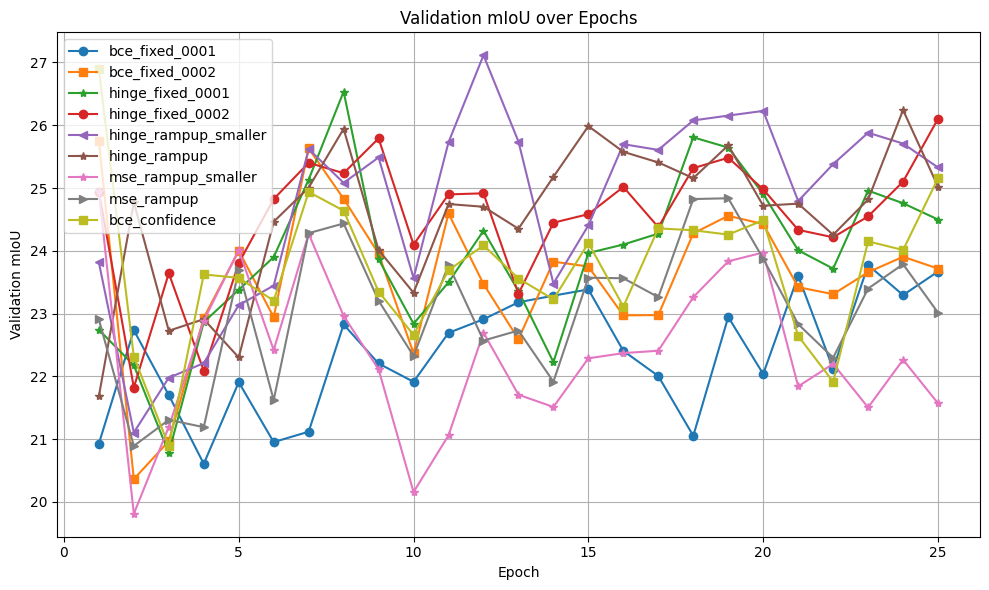

In [15]:
# Crea un asse delle epoche corretto (da 1 a 50)
epochs = range(1, len(val_miou_bce_fixed_0001) + 1)

# Plot
plt.figure(figsize=(10, 6))

plt.plot(epochs, val_miou_bce_fixed_0001, label='bce_fixed_0001', marker='o')
plt.plot(epochs, val_miou_bce_fixed_0002, label='bce_fixed_0002', marker='s')
plt.plot(epochs, val_miou_hinge_fixed_0001, label='hinge_fixed_0001', marker='*')
plt.plot(epochs, val_miou_hinge_fixed_0002, label='hinge_fixed_0002', marker='o')
plt.plot(epochs, val_miou_hinge_rampup_smaller, label='hinge_rampup_smaller', marker='<')
plt.plot(epochs, val_miou_hinge_rampup, label='hinge_rampup', marker='*')
plt.plot(epochs, val_miou_mse_rampup_smaller, label='mse_rampup_smaller', marker='*')
plt.plot(epochs, val_miou_mse_rampup, label='mse_rampup', marker='>')
plt.plot(epochs, val_miou_bce_confidence, label='bce_confidence', marker='s')


plt.title('Validation mIoU over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Validation mIoU')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [20]:
threshold = 25  # soglia più sensata per val_mIoU


df_summary = pd.DataFrame({
    'Mean': [val_miou_bce_fixed_0001.mean(), 
             val_miou_bce_fixed_0002.mean(),
             val_miou_hinge_fixed_0001.mean(),
             val_miou_hinge_fixed_0002.mean(),
             val_miou_hinge_rampup_smaller.mean(),
             val_miou_hinge_rampup.mean(),
             val_miou_mse_rampup_smaller.mean(),
             val_miou_mse_rampup.mean(),
             val_miou_bce_confidence.mean()
             ],
    'Max': [val_miou_bce_fixed_0001.max(), 
            val_miou_bce_fixed_0002.max(),
            val_miou_hinge_fixed_0001.max(),
            val_miou_hinge_fixed_0002.max(),
            val_miou_hinge_rampup_smaller.max(),
            val_miou_hinge_rampup.max(),
            val_miou_mse_rampup_smaller.max(),
            val_miou_mse_rampup.max(),
            val_miou_bce_confidence.max()
            ],
    'Min': [val_miou_bce_fixed_0001.min(), 
            val_miou_bce_fixed_0002.min(),
            val_miou_hinge_fixed_0001.min(),
            val_miou_hinge_fixed_0002.min(),
            val_miou_hinge_rampup_smaller.min(),
            val_miou_hinge_rampup.min(),
            val_miou_mse_rampup_smaller.min(),
            val_miou_mse_rampup.min(),
            val_miou_bce_confidence.min()
            ],
    'Std': [val_miou_bce_fixed_0001.std(), 
            val_miou_bce_fixed_0002.std(),
            val_miou_hinge_fixed_0001.std(),
            val_miou_hinge_fixed_0002.std(),
            val_miou_hinge_rampup_smaller.std(),
            val_miou_hinge_rampup.std(),
            val_miou_mse_rampup_smaller.std(),
            val_miou_mse_rampup.std(),
            val_miou_bce_confidence.std()

            ],
    'Best Epoch': [val_miou_bce_fixed_0001.idxmax() + 1, 
                   val_miou_bce_fixed_0002.idxmax() + 1,
                   val_miou_hinge_fixed_0001.idxmax() + 1,
                   val_miou_hinge_fixed_0002.idxmax() + 1,
                   val_miou_hinge_rampup_smaller.idxmax() + 1,
                   val_miou_hinge_rampup.idxmax() + 1,
                   val_miou_mse_rampup_smaller.idxmax() + 1,
                   val_miou_mse_rampup.idxmax() + 1,
                   val_miou_bce_confidence.idxmax() + 1

                   ],
    'AUC': [trapz(val_miou_bce_fixed_0001), 
            trapz(val_miou_bce_fixed_0002),
            trapz(val_miou_hinge_fixed_0001),
            trapz(val_miou_hinge_fixed_0002),
            trapz(val_miou_hinge_rampup_smaller),
            trapz(val_miou_hinge_rampup),
            trapz(val_miou_mse_rampup_smaller),
            trapz(val_miou_mse_rampup),
            trapz(val_miou_bce_confidence)
            ],
    f'Epochs > {threshold}': [(val_miou_bce_fixed_0001 > threshold).sum(), 
                              (val_miou_bce_fixed_0002 > threshold).sum(),
                              (val_miou_hinge_fixed_0001 > threshold).sum(),
                              (val_miou_hinge_fixed_0002 > threshold).sum(),
                              (val_miou_hinge_rampup_smaller > threshold).sum(),
                              (val_miou_hinge_rampup > threshold).sum(),
                              (val_miou_mse_rampup_smaller > threshold).sum(),
                              (val_miou_mse_rampup > threshold).sum(),
                              (val_miou_bce_confidence > threshold).sum()
                              ],
    'Trend': [
        np.polyfit(range(len(val_miou_bce_fixed_0001)),val_miou_bce_fixed_0001, 1)[0],
        np.polyfit(range(len(val_miou_bce_fixed_0002)), val_miou_bce_fixed_0002, 1)[0],
        np.polyfit(range(len(val_miou_hinge_fixed_0001)), val_miou_hinge_fixed_0001, 1)[0],
        np.polyfit(range(len(val_miou_hinge_fixed_0002)), val_miou_hinge_fixed_0002, 1)[0],
        np.polyfit(range(len(val_miou_hinge_rampup_smaller)), val_miou_hinge_rampup_smaller, 1)[0],
        np.polyfit(range(len(val_miou_hinge_rampup)), val_miou_hinge_rampup, 1)[0],
        np.polyfit(range(len(val_miou_mse_rampup_smaller)), val_miou_mse_rampup_smaller, 1)[0],
        np.polyfit(range(len(val_miou_mse_rampup)), val_miou_mse_rampup, 1)[0],
        np.polyfit(range(len(val_miou_bce_confidence)), val_miou_bce_confidence, 1)[0]


    ],
    'Final Epoch mIoU': [val_miou_bce_fixed_0001.iloc[-1], 
                         val_miou_bce_fixed_0002.iloc[-1],
                         val_miou_hinge_fixed_0001.iloc[-1],
                         val_miou_hinge_fixed_0002.iloc[-1],
                         val_miou_hinge_rampup_smaller.iloc[-1],
                         val_miou_hinge_rampup.iloc[-1],
                         val_miou_mse_rampup_smaller.iloc[-1],
                         val_miou_mse_rampup.iloc[-1],
                         val_miou_bce_confidence.iloc[-1]
                         ]
}, index=[
    'bce_fixed_0001',
    'bce_fixed_0002',
    'hinge_fixed_0001',
    'hinge_fixed_0002',
    'hinge_rampup_smaller',
    'hinge_rampup',
    'mse_rampup_smaller',
    'mse_rampup',
    'bce_confidence'
])

df_summary = df_summary.round(4)

def underline_best(s):
    return ['text-decoration: underline; font-weight: bold;' if v else '' for v in s]

styled_df = df_summary.style.set_caption("📊 Validation mIoU Summary Table") \
    .format(precision=4) \
    .set_table_styles([
        {'selector': 'caption', 'props': [('text-align', 'left'), ('font-size', '16px'), ('font-weight', 'bold')]},
        {'selector': 'th', 'props': [('background-color', 'white'), ('font-weight', 'bold'), ('color', 'black')]},
        {'selector': 'td', 'props': [('background-color', 'white'), ('color', 'black')]}
    ]) \
    .apply(lambda x: underline_best(x == x.max()), subset=['Mean', 'Max', 'Best Epoch', 'AUC', f'Epochs > {threshold}', 'Final Epoch mIoU', 'Trend']) \
    .apply(lambda x: underline_best(x == x.min()), subset=['Min', 'Std'])

display(styled_df)

,Mean,Max,Min,Std,Best Epoch,AUC,Epochs > 25,Trend,Final Epoch mIoU
bce_fixed_0001,22.3696,23.7716,20.6060,0.9426,23,536.9410,0,0.0762,23.6691
bce_fixed_0002,23.5677,25.7551,20.3628,1.2164,1,564.4580,2,0.0291,23.7164
hinge_fixed_0001,23.9296,26.5346,20.7812,1.2669,8,574.6192,4,0.0882,24.4978
hinge_fixed_0002,24.5312,26.1031,21.8217,1.0123,25,587.7558,8,0.0618,26.1031
hinge_rampup_smaller,24.7504,27.1146,21.1042,1.5162,12,594.1882,15,0.1368,25.3272
hinge_rampup,24.5491,26.2417,21.6832,1.1649,24,590.3767,10,0.0969,25.0201
mse_rampup_smaller,22.3700,24.9447,19.8102,1.2361,1,535.9924,0,-0.0116,21.5708
mse_rampup,23.0438,24.8366,20.8914,1.0923,19,553.1346,0,0.0623,23.0129
bce_confidence,23.7270,26.8903,20.8941,1.1770,1,567.1522,2,0.0126,25.1552


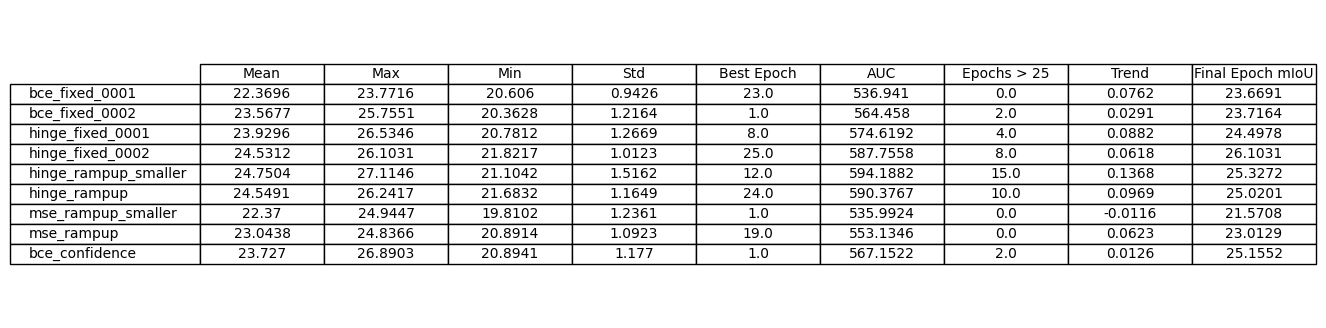

In [21]:
fig, ax = plt.subplots(figsize=(12, 4))  # adjust size to fit your table
ax.axis('off')

table = ax.table(cellText=df_summary.values,
                 colLabels=df_summary.columns,
                 rowLabels=df_summary.index,
                 cellLoc='center',
                 loc='center')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.savefig("validation_miou_summary.png", bbox_inches='tight', dpi=300)

#### Comments:
- The best one seems to be '2 Random Color or All Best Weather', since it has an overall higher mean, more epochs > 25, a higher AUC and a higher trend. 
- On the other hand, '2 Random Color' has a higher min valye, lower std and a higher Final Epoc mIoU, but overaal the other combiantion generally achieves better values and has a better trend.
- I SUGGEST WE CHOOSE '2 Random Color or All Best Weather' BETWEEN THESE 2.

## Metrics Explanation

| Column         | Description |
|----------------|-------------|
| **Mean**       | The average validation mIoU across all epochs. Gives a general sense of model performance over time. |
| **Max**        | The highest mIoU achieved during validation. Indicates peak performance. |
| **Min**        | The lowest mIoU recorded. Useful to assess consistency and worst-case performance. |
| **Std**        | The standard deviation of mIoU values. A lower value means the model is more stable across epochs. |
| **Best Epoch** | The epoch number (1-based) where the highest mIoU was achieved. |
| **AUC**        | The Area Under the Curve of the mIoU trend. A higher value reflects better performance over the full validation period. |
| **Epochs > 25** | Number of epochs where mIoU exceeded a threshold of 25. Useful to evaluate how consistently good the model is. |
| **Trend**      | The slope of a linear fit over all epochs. A positive value suggests performance is improving, while a negative one indicates degradation. |
